# Subject-wise Student Performance Predictor

A Machine Learning project that predicts a student's final marks for a selected subject based on study hours, attendance, previous marks, and assignment score.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## 1. Dataset Generation

A synthetic dataset of student academic performance is created for this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

n = 500

subjects = np.random.choice(
    ["Python", "DBMS", "DSA", "Mathematics", "Statistics"],
    n
)

study_hours = np.random.uniform(1, 10, n).round(1)
attendance = np.random.uniform(50, 100, n).round(1)
previous_marks = np.random.uniform(40, 90, n).round(1)
assignment_score = np.random.uniform(40, 100, n).round(1)

final_marks = (
    0.30 * study_hours * 10
    + 0.25 * attendance
    + 0.25 * previous_marks
    + 0.20 * assignment_score
    + np.random.normal(0, 4, n)
)

final_marks = np.clip(final_marks, 0, 100).round(1)

df = pd.DataFrame({
    "Subject": subjects,
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Previous_Marks": previous_marks,
    "Assignment_Score": assignment_score,
    "Final_Marks": final_marks
})

df.head()

,Subject,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
0,Mathematics,5.5,59.1,41.8,85.7,52.1
1,Statistics,8.4,79.2,76.8,42.1,69.4
2,DSA,3.9,71.1,73.2,84.7,68.6
3,Statistics,9.1,94.6,63.7,52.1,83.8
4,Statistics,4.5,90.9,82.2,97.5,71.3


In [4]:
df.shape

(500, 6)

## 2. Data Inspection

The dataset is checked for its structure, missing values, and basic statistical information.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Subject           500 non-null    object 
 1   Study_Hours       500 non-null    float64
 2   Attendance        500 non-null    float64
 3   Previous_Marks    500 non-null    float64
 4   Assignment_Score  500 non-null    float64
 5   Final_Marks       500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


In [6]:
df.isnull().sum()

,0
Subject,0
Study_Hours,0
Attendance,0
Previous_Marks,0
Assignment_Score,0
Final_Marks,0


In [7]:
df.describe()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
count,500.000000,500.00000,500.000000,500.000000,500.000000
mean,5.405600,75.43360,65.155000,69.752000,65.336000
std,2.644889,14.70896,14.513029,17.082802,10.792872
min,1.000000,50.30000,40.200000,40.100000,31.800000
25%,3.000000,62.30000,52.000000,55.600000,56.975000
50%,5.350000,75.95000,65.950000,70.100000,64.600000
75%,7.700000,88.40000,77.025000,83.950000,73.000000
max,10.000000,99.90000,90.000000,99.900000,93.300000


In [9]:
df["Subject"].value_counts( )

,count
Subject,
Mathematics,112
Python,109
DBMS,95
Statistics,93
DSA,91


## 3. Exploratory Data Analysis (EDA)

EDA is performed to understand the relationship between academic features and final marks.

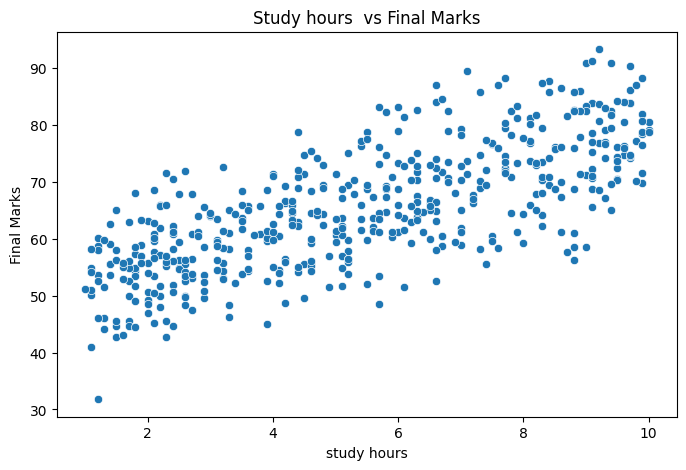

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Marks"
)

plt.title("Study hours  vs Final Marks")
plt.xlabel("study hours")
plt.ylabel("Final Marks")
plt.show()

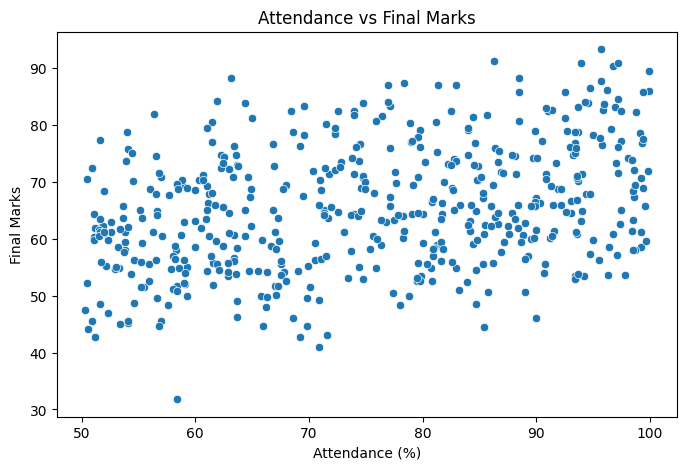

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Marks"
)

plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.show()

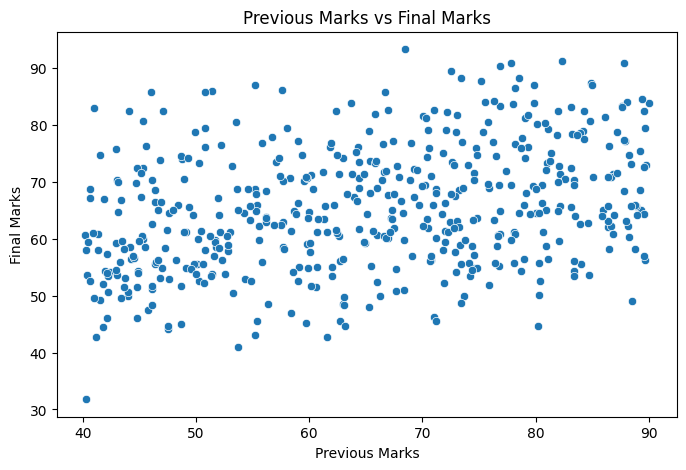

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Previous_Marks",
    y="Final_Marks"
)

plt.title("Previous Marks vs Final Marks")
plt.xlabel("Previous Marks")
plt.ylabel("Final Marks")
plt.show()

## 4. Feature Preparation

The categorical Subject feature is converted into numerical features using one-hot encoding.

In [14]:
df_encoded = pd.get_dummies(df, columns=["Subject"], dtype=int)

df_encoded.head()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks,Subject_DBMS,Subject_DSA,Subject_Mathematics,Subject_Python,Subject_Statistics
0,5.5,59.1,41.8,85.7,52.1,0,0,1,0,0
1,8.4,79.2,76.8,42.1,69.4,0,0,0,0,1
2,3.9,71.1,73.2,84.7,68.6,0,1,0,0,0
3,9.1,94.6,63.7,52.1,83.8,0,0,0,0,1
4,4.5,90.9,82.2,97.5,71.3,0,0,0,0,1


In [15]:
X = df_encoded.drop("Final_Marks", axis=1)
y = df_encoded["Final_Marks"]

print("Input features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Input features:
Index(['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score',
       'Subject_DBMS', 'Subject_DSA', 'Subject_Mathematics', 'Subject_Python',
       'Subject_Statistics'],
      dtype='object')

Target:
Final_Marks


## 5. Model Training

The dataset is divided into training and testing sets, followed by training a Linear Regression model.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 9)
Testing data: (100, 9)


## 5. Model Training

The dataset is divided into training and testing sets, followed by training a Linear Regression model.

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[71.3100981  82.95943349 59.99654674 49.22904567 79.24819417 73.28368703
 68.89193611 66.6034163  49.84866906 62.75039627]


In [19]:
comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred.round(1)
})

comparison.head(10)

,Actual Marks,Predicted Marks
0,73.5,71.3
1,88.2,83.0
2,54.5,60.0
3,51.5,49.2
4,76.9,79.2
5,69.7,73.3
6,69.9,68.9
7,64.5,66.6
8,51.0,49.8
9,65.6,62.8


## 6. Model Evaluation

The model is evaluated using R² Score and Mean Absolute Error (MAE).

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", round(r2, 3))
print("Mean Absolute Error:", round(mae, 2))

R² Score: 0.849
Mean Absolute Error: 3.26


## 7. New Student Prediction

The trained model is used to predict the final marks of a new student.

In [27]:
def predict_marks(subject, study_hours, attendance, previous_marks, assignment_score):

    input_data = pd.DataFrame({
        "Study_Hours": [study_hours],
        "Attendance": [attendance],
        "Previous_Marks": [previous_marks],
        "Assignment_Score": [assignment_score],
        "Subject_DSA": [1 if subject == "DSA" else 0],
        "Subject_DBMS": [1 if subject == "DBMS" else 0],
        "Subject_Mathematics": [1 if subject == "Mathematics" else 0],
        "Subject_Python": [1 if subject == "Python" else 0],
        "Subject_Statistics": [1 if subject == "Statistics" else 0]
    })

    # Model ke exact column order me arrange karo
    input_data = input_data.reindex(columns=X.columns, fill_value=0)

    prediction = model.predict(input_data)

    return round(prediction[0], 1)

In [28]:
predicted_marks = predict_marks(
    "DBMS",
    6,
    85,
    72,
    80
)

print("Predicted DBMS Marks:", predicted_marks)

Predicted DBMS Marks: 72.6


In [29]:
subject = input("Enter Subject (Python/DBMS/DSA/Mathematics/Statistics): ")

study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
previous_marks = float(input("Enter Previous Marks: "))
assignment_score = float(input("Enter Assignment Score: "))

result = predict_marks(
    subject,
    study_hours,
    attendance,
    previous_marks,
    assignment_score
)

print("\nPredicted Final Marks:", result)

Enter Subject (Python/DBMS/DSA/Mathematics/Statistics): 70
Enter Study Hours: 4
Enter Attendance (%): 75
Enter Previous Marks: 67
Enter Assignment Score: 40

Predicted Final Marks: 56.0


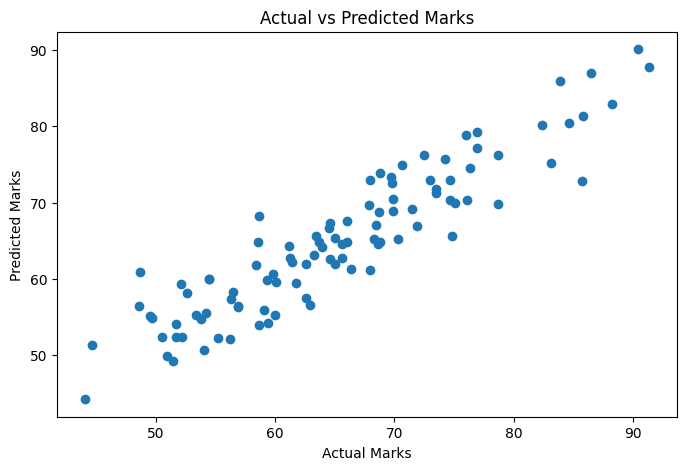

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,Study_Hours,3.073751
1,Attendance,0.222229
2,Previous_Marks,0.250358
3,Assignment_Score,0.178776
4,Subject_DBMS,-0.206204
5,Subject_DSA,0.220947
6,Subject_Mathematics,0.331843
7,Subject_Python,-0.186150
8,Subject_Statistics,-0.160436


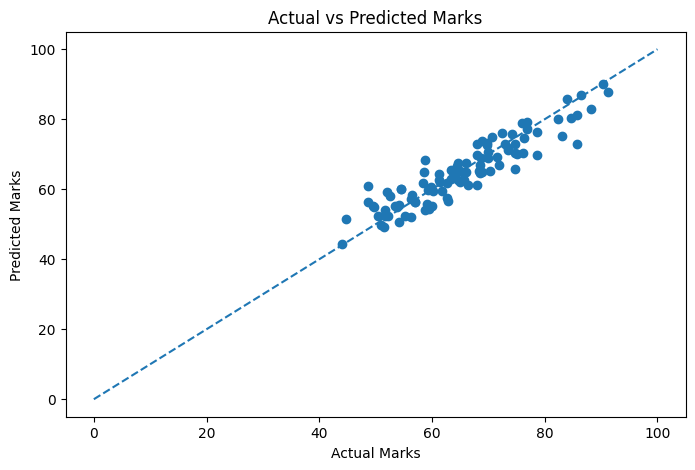

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)
plt.plot([0, 100], [0, 100], linestyle="--")

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

Project Workflow

1. Dataset Generation
2. Data Inspection & Cleaning
3. Exploratory Data Analysis (EDA)
4. Categorical Feature Encoding
5. Train-Test Split
6. Linear Regression Model Training
7. Model Prediction
8. Model Evaluation using R² and MAE
9. New Student Marks Prediction
10. Actual vs Predicted Visualization

In [34]:
# Example: Predict marks for a new student

subject = "DBMS"
study_hours = 6
attendance = 85
previous_marks = 72
assignment_score = 80

prediction = predict_marks(
    subject,
    study_hours,
    attendance,
    previous_marks,
    assignment_score
)

print("Subject:", subject)
print("Study Hours:", study_hours)
print("Attendance:", attendance, "%")
print("Previous Marks:", previous_marks)
print("Assignment Score:", assignment_score)
print("--------------------------------")
print("Predicted Final Marks:", prediction)

Subject: DBMS
Study Hours: 6
Attendance: 85 %
Previous Marks: 72
Assignment Score: 80
--------------------------------
Predicted Final Marks: 72.6


In [35]:
df.to_csv("student_performance_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [36]:
from google.colab import files

files.download("student_performance_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>